# 1 TLS Markovian Example

This example runs a full Markovian simulation in one function: parameter input, time evolution, expectation values, and plotting.

times[:8]             = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35]
tls_pop[:8]           = [1.         0.9508278  0.9040735  0.85961822 0.81734889 0.77715805
 0.73894348 0.702608  ]
photon_bins_l[:8]     = [0.         0.49172202 0.46754297 0.44455285 0.42269321 0.40190845
 0.38214573 0.36335478]
photon_bins_r[:8]     = [0.         0.49172202 0.46754297 0.44455285 0.42269321 0.40190845
 0.38214573 0.36335478]
emitted_l[:8]         = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
emitted_r[:8]         = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
total_excitation[:8]  = [1. 1. 1. 1. 1. 1. 1. 1.]
------------------------------------------------------------------------
final tls_pop         = 0.0003135444975289105
final emitted_l       = 0.49984322775123485
final emitted_r       = 0.49984322775123513
final total           = 0.9999999999999989
max |total-1|         = 1.3322676295501878e-15


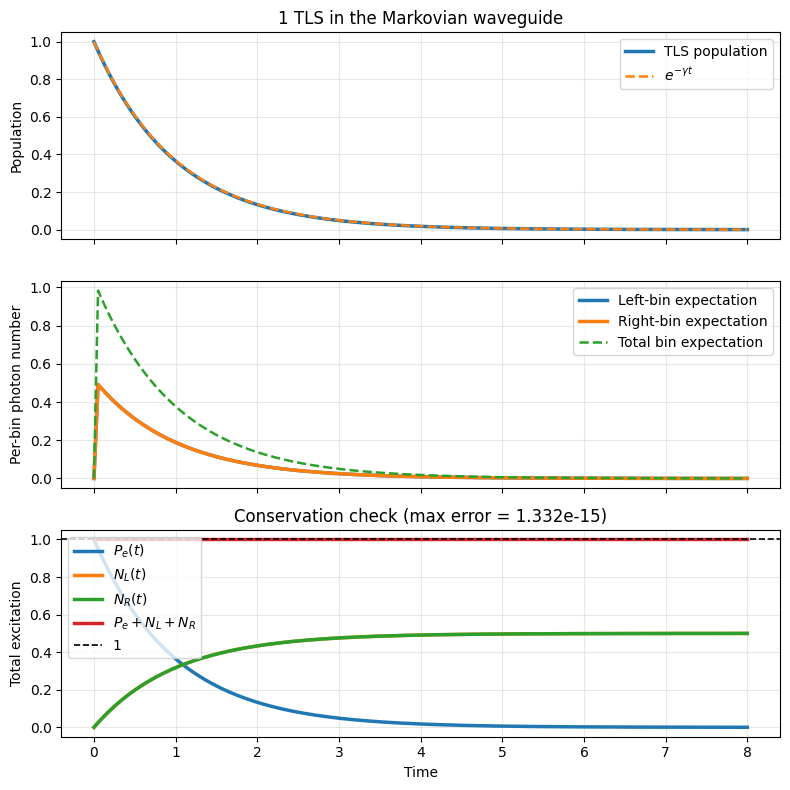

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import wqedmps as qmps


def run_markovian_tls_example() -> tuple[
    qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]
]:
    """Run the 1-TLS Markovian example from inputs to observables and plots."""
    # 1. Define the physical and numerical parameters.
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=8.0,
        d_sys_total=np.array([2]),
        d_t_total=np.array([2, 2]),
        gamma_l=0.5,
        gamma_r=0.5,
        bond_max=18,
    )

    # 2. Build the initial state and local Hamiltonian.
    initial_system = qmps.tls_excited()
    initial_field = qmps.wg_ground(params.d_t)
    hamiltonian = qmps.hamiltonian_1tls(params)

    # 3. Run the time evolution.
    bins = qmps.t_evol_mar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    # 4. Compute expectation values of the observables stored during evolution.
    times = np.asarray(bins.times, dtype=float)
    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.tls_pop(params.d_sys)),
        dtype=float,
    )
    output_bin_pop = np.asarray(
        qmps.single_time_expectation(
            bins.output_field_states,
            [qmps.num_op_l(params.d_t_total), qmps.num_op_r(params.d_t_total)],
        ),
        dtype=float,
    )
    photon_bins_l = output_bin_pop[0] / params.delta_t
    photon_bins_r = output_bin_pop[1] / params.delta_t

    # The first output bin is the pre-interaction bin, so emitted light starts at index 1.
    emitted_l = np.concatenate([[0.0], np.cumsum(photon_bins_l[1:])]) * params.delta_t
    emitted_r = np.concatenate([[0.0], np.cumsum(photon_bins_r[1:])]) * params.delta_t
    total_excitation = tls_pop + emitted_l + emitted_r

    observables = {
        "times": times,
        "tls_pop": tls_pop,
        "photon_bins_l": photon_bins_l,
        "photon_bins_r": photon_bins_r,
        "emitted_l": emitted_l,
        "emitted_r": emitted_r,
        "total_excitation": total_excitation,
        "max_abs_error": float(np.max(np.abs(total_excitation - 1.0))),
    }

    # 5. Plot TLS decay, output populations and the conservation diagnostic.
    gamma_total = params.gamma_l + params.gamma_r
    fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.0), sharex=True)

    axes[0].plot(times, tls_pop, lw=2.5, label="TLS population")
    axes[0].plot(
        times, np.exp(-gamma_total * times), "--", lw=1.8, label=rf"$e^{{-\gamma t}}$"
    )
    axes[0].set_ylabel("Population")
    axes[0].set_title("1 TLS in the Markovian waveguide")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, photon_bins_l, lw=2.5, label="Left-bin expectation")
    axes[1].plot(times, photon_bins_r, lw=2.5, label="Right-bin expectation")
    axes[1].plot(
        times,
        photon_bins_l + photon_bins_r,
        "--",
        lw=1.8,
        label="Total bin expectation",
    )
    axes[1].set_ylabel("Per-bin photon number")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(times, tls_pop, lw=2.5, label=r"$P_e(t)$")
    axes[2].plot(times, emitted_l, lw=2.5, label=r"$N_L(t)$")
    axes[2].plot(times, emitted_r, lw=2.5, label=r"$N_R(t)$")
    axes[2].plot(times, total_excitation, lw=2.5, label=r"$P_e + N_L + N_R$")
    axes[2].axhline(1.0, color="k", linestyle="--", lw=1.2, label="1")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Total excitation")
    axes[2].set_title(
        f"Conservation check (max error = {observables['max_abs_error']:.3e})"
    )
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return params, bins, observables


params, bins, observables = run_markovian_tls_example()
